# ↗️ NEWTON TOOLS — Resultante de Forças 2D
---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta permite determinar a **resultante de forças** $\vec{R}$ de $N$ forças $\vec{F}_i$ em duas dimensões: $$\vec{R}=\sum_{i=1}^N \vec{F}_i$$

Cada força pode ser inserida de duas formas:

- Componentes cartesianas: $F_x$ e $F_y$
- Componentes polares: módulo $|\vec{F}|$ e ângulo $\theta$

O ângulo $\theta$, em graus, pode ser medido em relação a qualquer um dos semieixos $+x$, $-x$, $+y$ e $-y$ no sentido horário `↻` ou no sentido anti-horário `↺`.

Todas as forças devem ser informadas usando a mesma unidade, informada no campo `Unidade`.

Após inserir todas as forças e selecionar `Calcular resultante`, a interface exibe:

- as componente cartesianas $R_x$ e $R_y$ da resultante $\vec{R}$
- as componentes polares $R=\vec{R}$ e $\theta$ da resultante $\vec{R}$
- um gráfico que mostra a resultante e as forças inseridas

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.

---
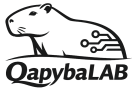

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **NEWTON TOOLS &mdash; Resultante de Forças 2D**
# ── Célula 1: Resultante de Forças 2D ───────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io, base64, warnings


# paleta de cores para os vetores
FORCE_COLORS = [
    '#1565c0', '#c62828', '#2e7d32', '#f57c00',
    '#6a1b9a', '#00695c', '#ad1457', '#4e342e',
]

# estado global
state = {'forces': [], 'force_widgets': [], 'unit': 'N'}


# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte QapybaLAB:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#    .res-t → tabela de dados (cabeçalho azul-marinho fixo)
#  Acento desta ferramenta: ciano #1098ad
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#1098ad;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#eafcff;border-left:4px solid #1098ad;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.res-t{border-collapse:collapse;font-size:.83rem;width:40%;margin:6px 0;}
.res-t th{background:#1a1a2e;color:#fff;padding:5px 10px;text-align:left;}
.res-t td{padding:4px 10px;text-align:left;border-bottom:1px solid #eee;
  font-family:monospace;}
.res-t tr:nth-child(odd) td{text-align:left}
.res-t tr:nth-child(even) td{background:#eafcff;text-align:left}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k, v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    """Constrói o HTML de um rótulo de seção (classe .sec)."""
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    """Widget HTML com um rótulo de seção — forma padrão de criar
    títulos de seção em toda a suíte LAB/NEWTON TOOLS."""
    return w.HTML(sec_html(texto, estilo))

def tabela_html(df):
    """Renderiza um DataFrame com o mesmo estilo .res-t usado nas
    demais ferramentas da suíte."""
    return df.to_html(classes="res-t", index=False, border=0,
                       float_format=lambda v: f"{v:.6g}")

def fig_para_html(fig):
    """Converte uma figura matplotlib em <img> embutido (PNG base64),
    no mesmo padrão visual usado nas demais ferramentas da suíte.
    Não fecha a figura — ela é reutilizada na exportação em PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:900px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.13)">')

# ESPECÍFICOS PARA ESTA FERRAMENTA
def _rad(deg):
    return np.deg2rad(deg)

def _cartesian_from_polar(mag, angle_deg, ref_axis, direction):
    # Converte (modulo, angulo) para (Fx, Fy).
    # ref_axis  : '+x', '-x', '+y', '-y'
    # direction : 'anti-horario' ou 'horario'
    origin_deg = {'+x': 0.0, '+y': 90.0, '-x': 180.0, '-y': 270.0}[ref_axis]
    if direction == 'anti-horário':
        theta = origin_deg + angle_deg
    else:
        theta = origin_deg - angle_deg
    return mag * np.cos(_rad(theta)), mag * np.sin(_rad(theta))

def _b64_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()

# ─── widget factory ───────────────────────────────────────────────────────────
def make_force_widget(index):
    color = FORCE_COLORS[index % len(FORCE_COLORS)]
    color_dot = (
        '<span style="display:inline-block;width:12px;height:12px;'
        'border-radius:50%;background:' + color + ';'
        'margin-right:6px;vertical-align:middle;"></span>'
    )
    header = widgets.HTML(
        '<div style="font-size:13px;font-weight:700;color:#1565c0;'
        'margin:0 0 8px 0;">' + color_dot +
        'Força F<sub>' + str(index + 1) + '</sub></div>'
    )

    fmt_toggle = widgets.ToggleButtons(
        options=[('Componentes cartesianas', 'cart'),
                 ('Módulo e ângulo', 'polar')],
        value='cart',
        style={'button_width': '200px'},
        layout=widgets.Layout(margin='0 0 8px 0'),
    )

    # cartesian panel
    fx_box = widgets.FloatText(description='Fx:', value=0.0,
                               layout=widgets.Layout(width='180px'))
    fy_box = widgets.FloatText(description='Fy:', value=0.0,
                               layout=widgets.Layout(width='180px'))
    cart_panel = widgets.HBox([fx_box, fy_box],
                              layout=widgets.Layout(margin='4px 0'))

    # polar panel
    mag_box = widgets.FloatText(description='Módulo:', value=0.0,
                                layout=widgets.Layout(width='185px'))
    ang_box = widgets.FloatText(description='Ângulo (°):', value=0.0,
                                layout=widgets.Layout(width='185px'))
    ref_radio = widgets.RadioButtons(
        options=['+x', '-x', '+y', '-y'],
        value='+x',
        description='Semieixo de ref.:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='280px'),
    )
    dir_radio = widgets.RadioButtons(
        options=['anti-horário', 'horário'],
        value='anti-horário',
        description='Sentido:',
        style={'description_width': '70px'},
        layout=widgets.Layout(width='200px'),
    )
    polar_panel = widgets.VBox([
        widgets.HBox([mag_box, ang_box]),
        widgets.HBox([ref_radio, dir_radio]),
    ], layout=widgets.Layout(margin='4px 0'))

    input_container = widgets.Box([cart_panel],
                                  layout=widgets.Layout(margin='0'))

    def _on_fmt(change):
        if change['new'] == 'cart':
            input_container.children = [cart_panel]
        else:
            input_container.children = [polar_panel]

    fmt_toggle.observe(_on_fmt, names='value')

    container = widgets.VBox(
        [header, fmt_toggle, input_container],
        layout=widgets.Layout(
            border='1px solid #d0d8f0',
            padding='12px 18px',
            margin='0 0 10px 0',
        )
    )

    return {
        'widget': container,
        'fmt': fmt_toggle,
        'fx': fx_box, 'fy': fy_box,
        'mag': mag_box, 'ang': ang_box,
        'ref': ref_radio, 'dir': dir_radio,
    }

def get_cartesian(fw):
    if fw['fmt'].value == 'cart':
        return fw['fx'].value, fw['fy'].value
    else:
        return _cartesian_from_polar(
            fw['mag'].value, fw['ang'].value,
            fw['ref'].value, fw['dir'].value
        )


# ─── plot ─────────────────────────────────────────────────────────────────────
def make_vector_plot(forces_xy, unit):
    Rx = sum(f[0] for f in forces_xy)
    Ry = sum(f[1] for f in forces_xy)

    fig, ax = plt.subplots(figsize=(6, 5), facecolor='#f7f9ff')
    ax.set_facecolor('#f7f9ff')

    all_vals = [abs(c) for f in forces_xy for c in f] + [abs(Rx), abs(Ry), 1e-9]
    span = max(all_vals)
    lim = span * 1.35

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='#aaaaaa', linewidth=0.8, zorder=1)
    ax.axvline(0, color='#aaaaaa', linewidth=0.8, zorder=1)
    ax.set_aspect('equal')
    ax.grid(True, color='#d0d8f0', linewidth=0.5, linestyle='--', zorder=0)
    ax.tick_params(labelsize=9)
    ax.set_xlabel('Fx (' + unit + ')', fontsize=10)
    ax.set_ylabel('Fy (' + unit + ')', fontsize=10)
    ax.set_title('Representação Vetorial das Forças', fontsize=12,
                 fontweight='bold', color='#1a237e', pad=10)

    kw = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
    patches = []

    for i, (fx, fy) in enumerate(forces_xy):
        c = FORCE_COLORS[i % len(FORCE_COLORS)]
        ax.quiver(0, 0, fx, fy, color=c, zorder=3, **kw)
        label = 'F' + str(i+1) + ' = (' + f'{fx:.3g}' + ', ' + f'{fy:.3g}' + ') ' + unit
        patches.append(mpatches.Patch(color=c, label=label))

    ax.quiver(0, 0, Rx, Ry, color='#000000', zorder=4,
              width=0.016, angles='xy', scale_units='xy', scale=1)
    patches.append(mpatches.Patch(color='black',
                                  label='R = (' + f'{Rx:.3g}' + ', ' + f'{Ry:.3g}' + ') ' + unit))

    ax.legend(handles=patches, fontsize=8.5, loc='upper left',
              framealpha=0.9, edgecolor='#c0cce0')
    fig.tight_layout(pad=1.5)
    return _b64_fig(fig)


# ----------------------- Cabeçalho -----------------------

cabecalho = widgets.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; NEWTON TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">↗️ Resultante de Forças 2D</div>
</div>
''')

# ----------------------- Interface -----------------------
# ─── main layout ──────────────────────────────────────────────────────────────
unit_box = widgets.Text(
    value='N',
    description='Unidade:',
    placeholder='ex.: N, kN, lbf ...',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='220px'),
)

unit_row = widgets.HBox([
    widgets.HTML('<div style="font-size:13px;font-weight:700;letter-spacing:2px;'
                 'text-transform:uppercase;color:#1565c0;border-bottom:2px solid #1565c0;'
                 'padding-bottom:3px;margin-right:16px;">Unidade</div>'),
    unit_box,
], layout=widgets.Layout(align_items='center', margin='0 0 16px 0'))

forces_area = widgets.VBox([])

btn_add = widgets.Button(
    description='  Inserir nova força',
    icon='plus',
    layout=widgets.Layout(width='220px', height='36px'),
)
btn_add.style.button_color = '#e8edf8'
btn_add.style.font_weight = '700'

btn_calc = widgets.Button(
    description='  Calcular resultante',
    icon='calculator',
    layout=widgets.Layout(width='220px', height='36px'),
    button_style='primary',
)
btn_calc.style.button_color = '#1565c0'
btn_calc.style.font_weight = '700'

btn_row = widgets.HBox([btn_add, btn_calc],
                       layout=widgets.Layout(margin='12px 0'))

result_out = widgets.Output()

main_ui = widgets.VBox([
    cabecalho,
    unit_row,
    widgets.HTML('<div style="font-size:13px;font-weight:700;letter-spacing:2px;'
                 'text-transform:uppercase;color:#1565c0;border-bottom:2px solid #1565c0;'
                 'padding-bottom:3px;margin:0 0 12px 0;">Forças</div>'),
    forces_area,
    btn_row,
    result_out,
])

# ─── callbacks ────────────────────────────────────────────────────────────────
def add_force(_=None):
    idx = len(state['force_widgets'])
    fw = make_force_widget(idx)
    state['force_widgets'].append(fw)
    forces_area.children = [fw['widget'] for fw in state['force_widgets']]

def calc_resultante(_=None):
    if not state['force_widgets']:
        with result_out:
            clear_output(wait=True)
            display(HTML('<p style="color:#c62828;font-weight:600;">'
                         '&#9888; Adicione ao menos uma força antes de calcular.</p>'))
        return

    unit = unit_box.value.strip() or 'N'
    forces_xy = [get_cartesian(fw) for fw in state['force_widgets']]

    Rx = sum(f[0] for f in forces_xy)
    Ry = sum(f[1] for f in forces_xy)
    mag_R = float(np.hypot(Rx, Ry))
    ang_R = float(np.degrees(np.arctan2(Ry, Rx)) % 360)

    b64 = make_vector_plot(forces_xy, unit)

    force_rows = ''
    for i, (fx, fy) in enumerate(forces_xy):
        c = FORCE_COLORS[i % len(FORCE_COLORS)]
        force_rows += (
            '<tr>'
            '<td style="padding:4px 10px;">'
            '<span style="display:inline-block;width:10px;height:10px;'
            'border-radius:50%;background:' + c + ';margin-right:6px;vertical-align:middle;"></span>'
            '<b>F<sub>' + str(i+1) + '</sub></b></td>'
            '<td style="padding:4px 10px;color:#333;">' + f'{fx:.4g}' + ' ' + unit + '</td>'
            '<td style="padding:4px 10px;color:#333;">' + f'{fy:.4g}' + ' ' + unit + '</td>'
            '</tr>'
        )

    section = ('<div style="font-size:13px;font-weight:700;letter-spacing:2px;'
               'text-transform:uppercase;color:#1565c0;border-bottom:2px solid #1565c0;'
               'padding-bottom:3px;margin:18px 0 10px 0;">')
    box = ('<div style="background:#f0f4ff;border-left:4px solid #1565c0;'
           'border-radius:6px;padding:12px 20px;margin:8px 0;">')
    lbl = '<div style="font-size:11px;font-weight:700;letter-spacing:2px;text-transform:uppercase;color:#1565c0;margin-bottom:4px;">'
    val = '<div style="font-size:15px;font-weight:600;color:#0d1b3e;">'

    html = (
        section + 'Resultado</div>'
        + box
        + lbl + 'A &mdash; Componentes cartesianas da resultante</div>'
        + val
        + 'R<sub>x</sub> = <b>' + f'{Rx:.4g}' + ' ' + unit + '</b>'
        + ' &nbsp;&nbsp;|&nbsp;&nbsp; '
        + 'R<sub>y</sub> = <b>' + f'{Ry:.4g}' + ' ' + unit + '</b>'
        + '</div></div>'
        + box
        + lbl + 'B &mdash; M&oacute;dulo e &acirc;ngulo (&theta; a partir de +x, sentido anti-hor&aacute;rio ↺)</div>'
        + val
        + '|R| = <b>' + f'{mag_R:.4g}' + ' ' + unit + '</b>'
        + ' &nbsp;&nbsp;|&nbsp;&nbsp; '
        + '&theta; = <b>' + f'{ang_R:.2f}' + '&deg;</b>'
        + '</div></div>'
        + section + 'Resumo das For&ccedil;as Inseridas</div>'
        + '<table style="border-collapse:collapse;font-size:13px;margin-bottom:14px;">'
        + '<thead><tr style="background:#e8edf8;color:#1a237e;">'
        + '<th style="padding:5px 10px;">For&ccedil;a</th>'
        + '<th style="padding:5px 10px;">Componente x</th>'
        + '<th style="padding:5px 10px;">Componente y</th>'
        + '</tr></thead><tbody>'
        + force_rows
        + '<tr style="border-top:2px solid #1565c0;font-weight:700;color:#1a237e;">'
        + '<td style="padding:5px 10px;">Resultante R</td>'
        + '<td style="padding:5px 10px;">' + f'{Rx:.4g}' + ' ' + unit + '</td>'
        + '<td style="padding:5px 10px;">' + f'{Ry:.4g}' + ' ' + unit + '</td>'
        + '</tr></tbody></table>'
        + section + 'C &mdash; Representa&ccedil;&atilde;o Vetorial</div>'
        + '<img src="data:image/png;base64,' + b64 + '"'
        + ' style="max-width:560px;width:100%;border-radius:8px;'
        + 'box-shadow:0 2px 10px rgba(21,101,192,0.12);" />'
    )

    with result_out:
        clear_output(wait=True)
        display(HTML(html))

btn_add.on_click(add_force)
btn_calc.on_click(calc_resultante)

# primeira força já inserida
add_force()

display(main_ui)